In [2]:
# Importing Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [3]:
# Loading Dataset

from sklearn.datasets import load_diabetes

data = load_diabetes()

X_raw = data.data
y_raw = data.target
feature_names = data.feature_names


In [4]:
X_raw
y_raw
feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [5]:
# Creating DataFrame

df = pd.DataFrame(X_raw, columns=feature_names)
df["target"] = y_raw

print("Dataset created as DataFrame")
print("df shape")
print(df.shape)
print("First rows")
print(df.head())


Dataset created as DataFrame
df shape
(442, 11)
First rows
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [6]:
# Understanding Dataset

print("Head")
print(df.head())

print("Tail")
print(df.tail())

print("Shape")
print(df.shape)

print("Columns")
print(df.columns.tolist())

print("Info")
print(df.info())

print("Describe")
print(df.describe())

print("Datatype checking")
print(df.dtypes)


Head
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
Tail
          age       sex       bmi        bp        s1        s2        s3  \
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0

In [7]:
# Missing Values Checking

missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values count for each column")
print(missing_values)


Missing values count for each column
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


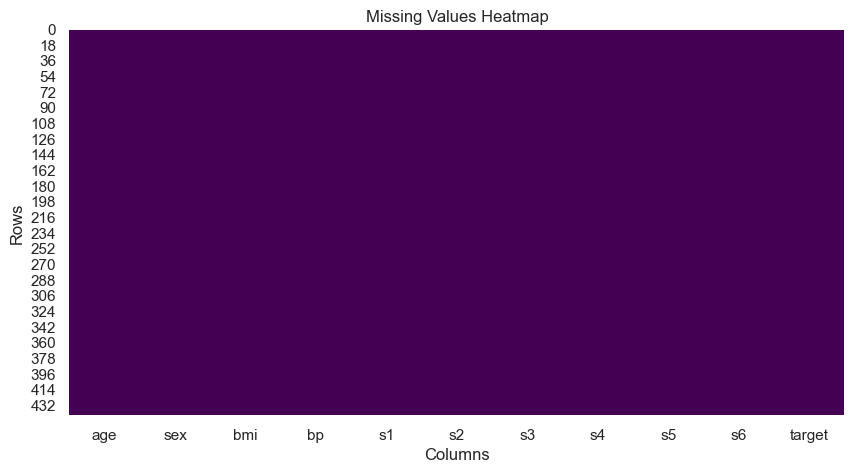

In [8]:
# Missing Values Visualization

plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


In [ ]:
# Outlier Detection


print("Checking distribution before outlier handling")
print(df.describe())


Checking distribution before outlier handling
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std  

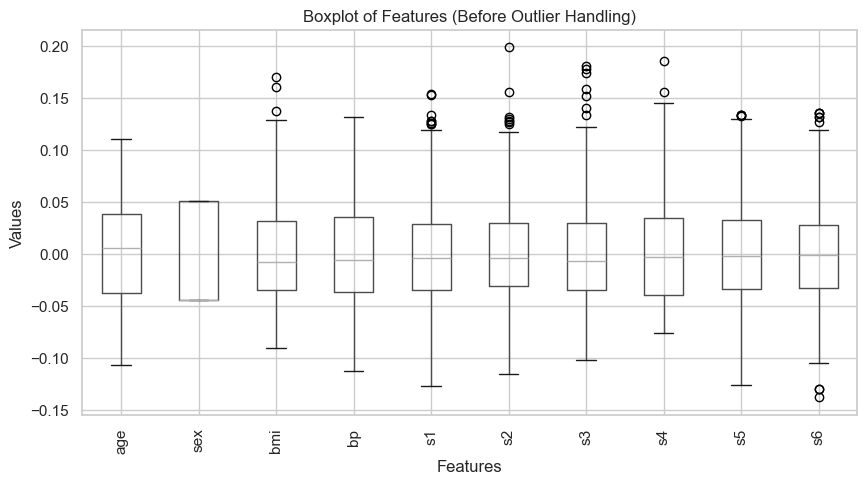

In [10]:
# Outlier Visualization Before Handling

plt.figure()
df.drop(columns=["target"]).boxplot(rot=90)
plt.title("Boxplot of Features (Before Outlier Handling)")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()


In [11]:
# Outlier Handling using IQR Method

df_clean = df.copy()

feature_cols = [col for col in df_clean.columns if col != "target"]

for col in feature_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace outliers with NaN, then fill with median
    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    df_clean.loc[outlier_mask, col] = np.nan

    # Fill NaNs introduced by outlier handling
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Outlier handling completed using IQR method")
print("Check for remaining NaNs")
print(df_clean.isnull().sum().sort_values(ascending=False))


Outlier handling completed using IQR method
Check for remaining NaNs
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


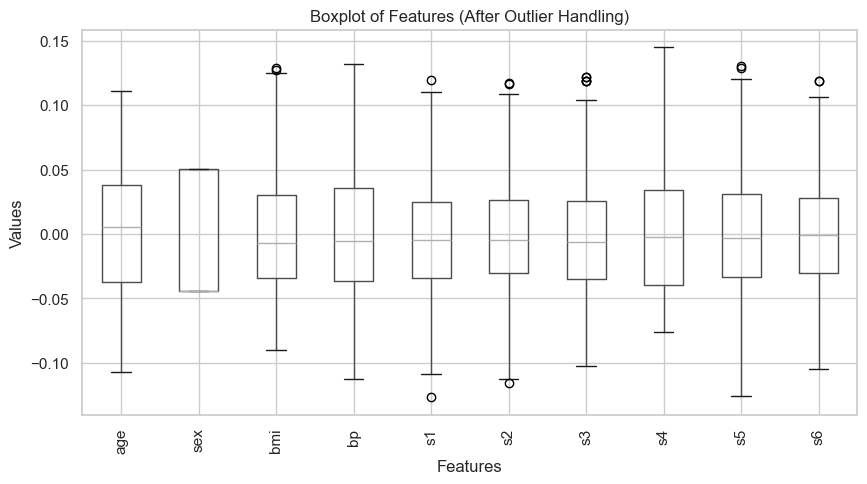

In [12]:
# Outlier Visualization After Handling

plt.figure()
df_clean.drop(columns=["target"]).boxplot(rot=90)
plt.title("Boxplot of Features (After Outlier Handling)")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()


In [13]:
# Feature and Target Separation

X = df_clean.drop(columns=["target"])
y = df_clean["target"]

print("Feature matrix X shape")
print(X.shape)
print("Target vector y shape")
print(y.shape)

print("X columns")
print(X.columns.tolist())


Feature matrix X shape
(442, 10)
Target vector y shape
(442,)
X columns
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [14]:
# Feature Scaling using StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling completed")
print("Scaled X shape")
print(X_scaled_df.shape)
print("Scaled X preview")
print(X_scaled_df.head())


Scaling completed
Scaled X shape
(442, 10)
Scaled X preview
        age       sex       bmi        bp        s1        s2        s3  \
0  0.800500  1.065488  1.372276  0.459841 -0.949827 -0.740385 -0.948374   
1 -0.039567 -0.938537 -1.100442 -0.553505 -0.135366 -0.383635  1.792212   
2  1.793307  1.065488  0.995481 -0.119214 -0.981153 -0.726115 -0.691444   
3 -1.872441 -0.938537 -0.229103 -0.770650  0.334516  0.622400 -0.777087   
4  0.113172 -0.938537 -0.770747  0.459841  0.146563  0.408350  0.250633   

         s4        s5        s6  
0 -0.039221  0.461343 -0.383234  
1 -0.838847 -1.464030 -2.092321  
2 -0.039221  0.089396 -0.573133  
3  0.760404  0.522009 -0.193336  
4 -0.039221 -0.671007 -1.047879  


In [15]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features shape")
print(X_train.shape)
print("Testing features shape")
print(X_test.shape)
print("Training target shape")
print(y_train.shape)
print("Testing target shape")
print(y_test.shape)


Training features shape
(353, 10)
Testing features shape
(89, 10)
Training target shape
(353,)
Testing target shape
(89,)


In [17]:
# AdaBoost Regressor Model Creation
model = AdaBoostRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",300
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.05
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [18]:
# Model Training

model.fit(X_train, y_train)

print("Model training completed")


Model training completed


In [19]:
# Model Prediction

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Predictions completed")
print("Train predictions shape")
print(y_pred_train.shape)
print("Test predictions shape")
print(y_pred_test.shape)


Predictions completed
Train predictions shape
(353,)
Test predictions shape
(89,)


In [20]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MAE")
print(mae)
print("MSE")
print(mse)
print("RMSE")
print(rmse)
print("R2 Score")
print(r2)


MAE
43.000962933205145
MSE
2776.654467555223
RMSE
52.69396993542262
R2 Score
0.47592017002294384


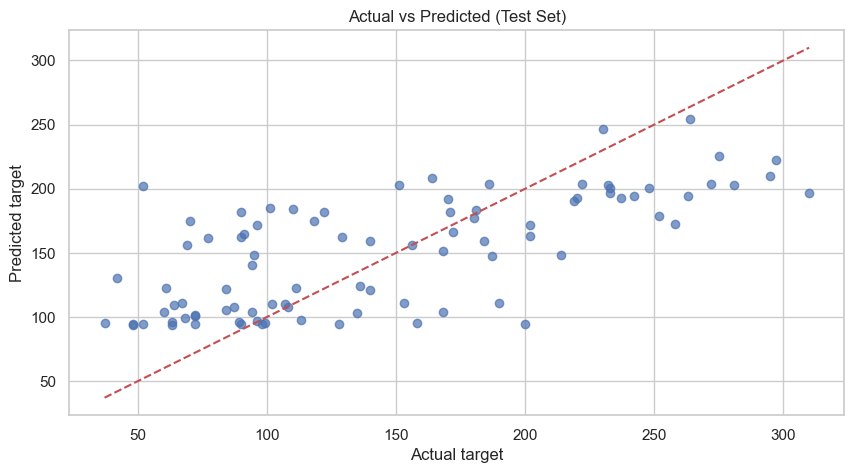

In [21]:
# Actual vs Predicted Visualization

plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted (Test Set)")
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.show()


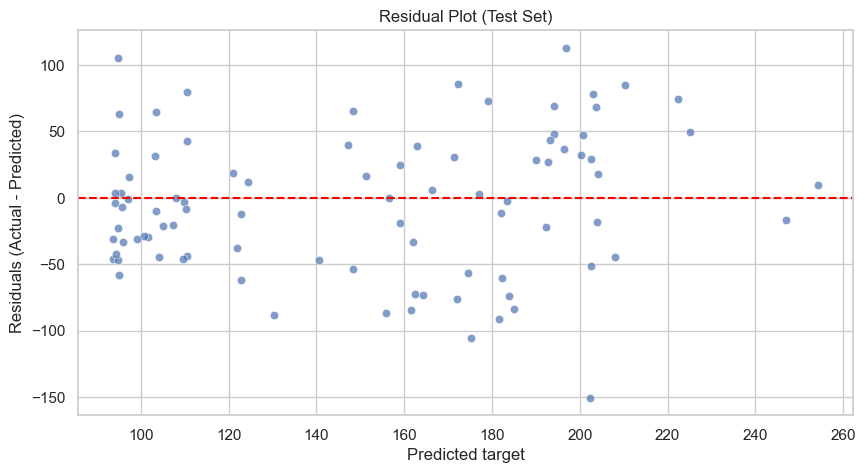

Residuals summary
count     89.000000
mean      -4.424547
std       52.805381
min     -150.381818
25%      -44.117117
50%       -4.092593
75%       32.641975
max      113.088757
Name: target, dtype: float64


In [22]:
# Residual Plot

residuals = y_test - y_pred_test

plt.figure()
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot (Test Set)")
plt.xlabel("Predicted target")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

print("Residuals summary")
print(pd.Series(residuals).describe())


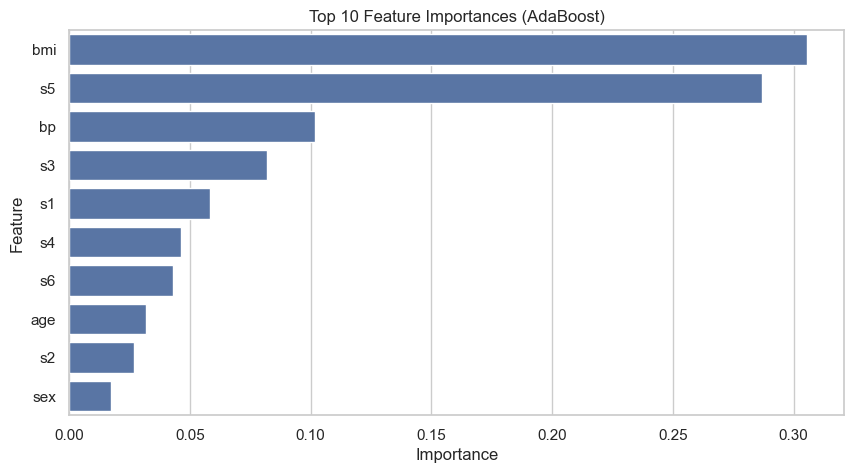

Feature importances available
  feature  importance
2     bmi    0.305733
8      s5    0.286884
3      bp    0.101855
6      s3    0.082011
4      s1    0.058335
7      s4    0.046383
9      s6    0.042953
0     age    0.031846
5      s2    0.026908
1     sex    0.017093


In [ ]:
# Feature Importance Visualization

feature_importances = None

if hasattr(model, "feature_importances_"):
    feature_importances = model.feature_importances_
elif hasattr(model, "estimators_"):
    # Try to derive importance from tree-based estimators (if present)
    # This fallback tries to compute average feature importances if available.
    importances_list = []
    for est in model.estimators_:
        if hasattr(est, "feature_importances_"):
            importances_list.append(est.feature_importances_)
    if len(importances_list) > 0:
        feature_importances = np.mean(importances_list, axis=0)

if feature_importances is not None:
    fi_df = pd.DataFrame(
        {"feature": X.columns, "importance": feature_importances}
    ).sort_values(by="importance", ascending=False)

    plt.figure()
    sns.barplot(x="importance", y="feature", data=fi_df.head(10), orient="h")
    plt.title("Top 10 Feature Importances (AdaBoost)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    print("Feature importances available")
    print(fi_df.head(10))
else:
    print("Feature importance not directly available for this configuration.")
    print("Skipping feature importance visualization.")


In [25]:
# Training Score and Testing Score

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Training R2 Score")
print(train_r2)
print("Testing R2 Score")
print(test_r2)


Training R2 Score
0.6023952151519837
Testing R2 Score
0.47592017002294384


In [26]:
# Overfitting and Underfitting Checking

print("Overfitting/Underfitting Check (using R2 comparison)")
print("Training R2")
print(train_r2)
print("Testing R2")
print(test_r2)

if train_r2 > test_r2 + 0.1:
    print("Likely overfitting: training performance is much better than testing performance.")
elif test_r2 < 0.5:
    print("Possible underfitting: testing performance is relatively low.")
else:
    print("Model seems reasonably balanced (no strong overfitting/underfitting indicator).")


Overfitting/Underfitting Check (using R2 comparison)
Training R2
0.6023952151519837
Testing R2
0.47592017002294384
Likely overfitting: training performance is much better than testing performance.
